# Выбор локации для скважины

# Описание проекта

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

# Описание данных


Данные геологоразведки трёх регионов находятся в файлах: 
    
- `/datasets/geo_data_0.csv.` 
- `/datasets/geo_data_1.csv.` 
- `/datasets/geo_data_2.csv.`
- *id* — уникальный идентификатор скважины;
- *f0, f1, f2* — три признака точек (неважно, что они означают, но сами признаки значимы);
- *product* — объём запасов в скважине (тыс. баррелей).

**Условия задачи:**

- Для обучения модели подходит только линейная регрессия (остальные — недостаточно предсказуемые).
- При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки.
- Бюджет на разработку скважин в регионе — 10 млрд рублей.
- При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей.
- После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

Данные синтетические: детали контрактов и характеристики месторождений не разглашаются.

## Загрузка и подготовка данных

1. Загрузите и подготовьте данные. Поясните порядок действий.

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from IPython.display import Markdown, display 
from scipy.stats import spearmanr
from scipy.stats import percentileofscore

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (15,10)

In [3]:
geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv')
geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv')
geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv')

In [4]:
display(geo_data_0.info())
display(geo_data_1.info())
display(geo_data_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

In [5]:
display('geo_data_0:', geo_data_0.describe(percentiles=[0.05, 1/4, 1/2, 3/4, 0.95, 0.99]).T)
display('geo_data_1:', geo_data_1.describe(percentiles=[0.05, 1/4, 1/2, 3/4, 0.95, 0.99]).T)
display('geo_data_2:', geo_data_2.describe(percentiles=[0.05, 1/4, 1/2, 3/4, 0.95, 0.99]).T)

'geo_data_0:'

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
f0,100000.0,0.500419,0.871832,-1.408605,-0.940431,-0.072580,0.502360,1.073581,1.939265,2.082334,2.362331
f1,100000.0,0.250143,0.504433,-0.848218,-0.514661,-0.200881,0.250252,0.700646,1.015524,1.121338,1.343769
f2,100000.0,2.502647,3.248248,-12.088328,-2.862016,0.287748,2.515969,4.715088,7.840264,9.969349,16.003790
product,100000.0,92.500000,44.288691,0.000000,24.019137,56.497507,91.849972,128.564089,161.206333,180.351516,185.364347


'geo_data_1:'

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
f0,100000.0,1.141296,8.965932,-31.609576,-12.706888,-6.298551,1.153055,8.621015,15.024181,18.863531,29.421755
f1,100000.0,-4.796579,5.119872,-26.358598,-13.190846,-8.267985,-4.813172,-1.332816,3.667425,7.139352,18.734063
f2,100000.0,2.494541,1.703572,-0.018144,-0.002644,1.000021,2.011479,3.999904,5.002640,5.007810,5.019721
product,100000.0,68.825000,45.944423,0.000000,0.000000,26.953261,57.085625,107.813044,137.945408,137.945408,137.945408


'geo_data_2:'

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
f0,100000.0,0.002023,1.732045,-8.760004,-2.847974,-1.162288,0.009424,1.158535,2.851247,4.057783,7.238262
f1,100000.0,-0.002081,1.730417,-7.084020,-2.836316,-1.174820,-0.009482,1.163678,2.845834,4.020189,7.844801
f2,100000.0,2.495128,3.473445,-11.970335,-3.193020,0.130359,2.484236,4.858794,8.227100,10.511973,16.739402
product,100000.0,95.000000,44.749921,0.000000,24.678170,59.450441,94.925613,130.595027,165.665158,184.995815,190.029838


In [6]:
display('Пропуски geo_data_0:', geo_data_0.isna().sum())
display('Пропуски geo_data_1:',geo_data_0.isna().sum())
display('Пропуски geo_data_2:', geo_data_0.isna().sum())

'Пропуски geo_data_0:'

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

'Пропуски geo_data_1:'

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

'Пропуски geo_data_2:'

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

In [7]:
def check_duplicates(geo_data):
    display(f'Дубликаты: {geo_data.duplicated().sum()}')

geo_data_list = [geo_data_0, geo_data_1, geo_data_2]

for geo_data in geo_data_list:
    check_duplicates(geo_data)

'Дубликаты: 0'

'Дубликаты: 0'

'Дубликаты: 0'

In [8]:
geo_data_0.nunique()
display('Уникальные значения в geo_data_0:', geo_data_0.nunique())
display('Уникальные значения в geo_data_1:', geo_data_1.nunique())
display('Уникальные значения в geo_data_2:', geo_data_2.nunique())

'Уникальные значения в geo_data_0:'

id          99990
f0         100000
f1         100000
f2         100000
product    100000
dtype: int64

'Уникальные значения в geo_data_1:'

id          99996
f0         100000
f1         100000
f2         100000
product        12
dtype: int64

'Уникальные значения в geo_data_2:'

id          99996
f0         100000
f1         100000
f2         100000
product    100000
dtype: int64

In [9]:
geo_data_1['product'].unique()

array([  3.17910258,  26.95326103, 134.76630516, 137.94540774,
        84.03888568, 110.99214671,  53.90652206,   0.        ,
       107.81304413,  57.08562465,  30.13236361,  80.85978309])

In [10]:
geo_data_1.query('product < 1')

,id,f0,f1,f2,product
11,OXyvW,16.320755,-0.562946,-0.001783,0.0
13,igmai,6.695604,-0.749449,-0.007630,0.0
62,Qjy5w,21.418478,-5.134490,-0.002836,0.0
63,G6WCj,6.822701,3.104979,-0.000723,0.0
77,MzQhL,6.750150,-11.893512,-0.001601,0.0
...,...,...,...,...,...
99936,YrRU8,5.085749,-3.980305,0.005063,0.0
99948,Jbnur,8.277805,-9.178818,0.003275,0.0
99956,aV1cJ,13.343983,-1.290200,0.005980,0.0
99961,Zjbn2,13.854163,-11.528089,-0.005556,0.0


In [11]:
x= 100000/8235
print(f'{x:.2f}%')

12.14%


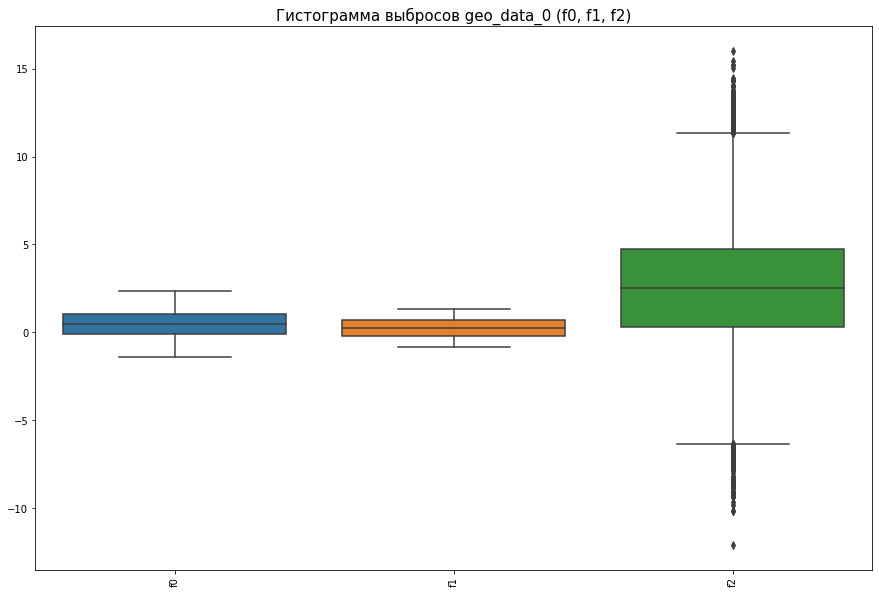

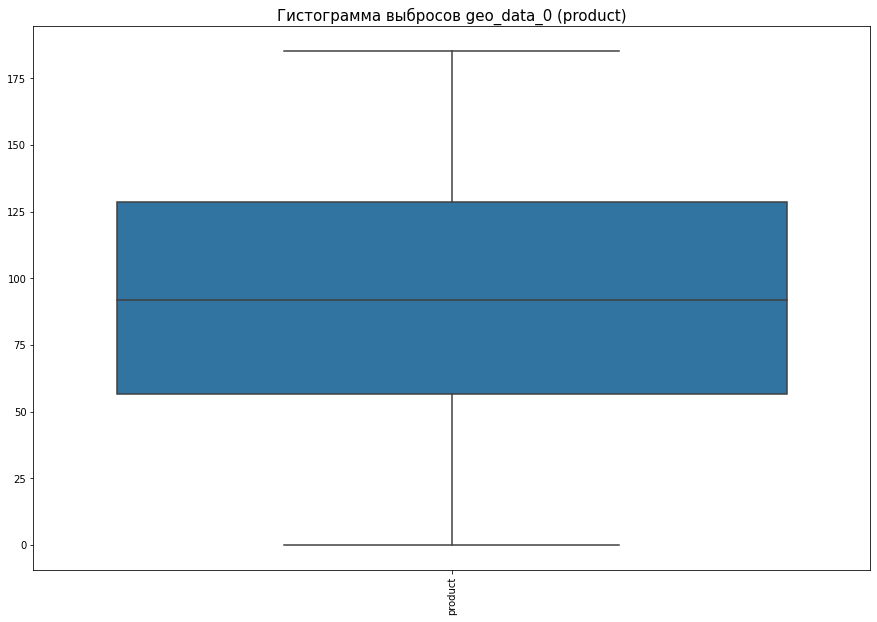

In [12]:
ax = sns.boxplot(data=geo_data_0.iloc[:,1:4])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Гистограмма выбросов geo_data_0 (f0, f1, f2)', size=15)
plt.show()
ax = sns.boxplot(data=geo_data_0.iloc[:,4:])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Гистограмма выбросов geo_data_0 (product)', size=15)
plt.show()

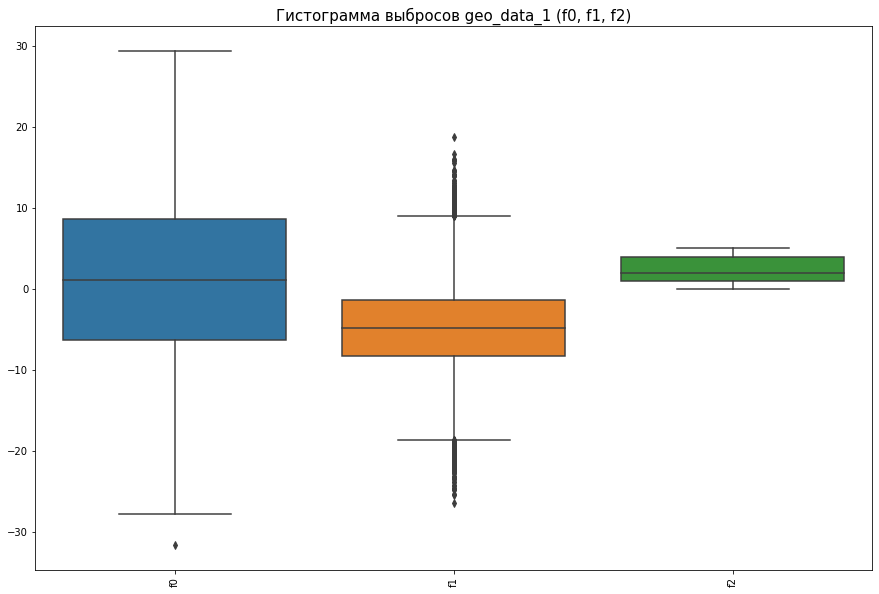

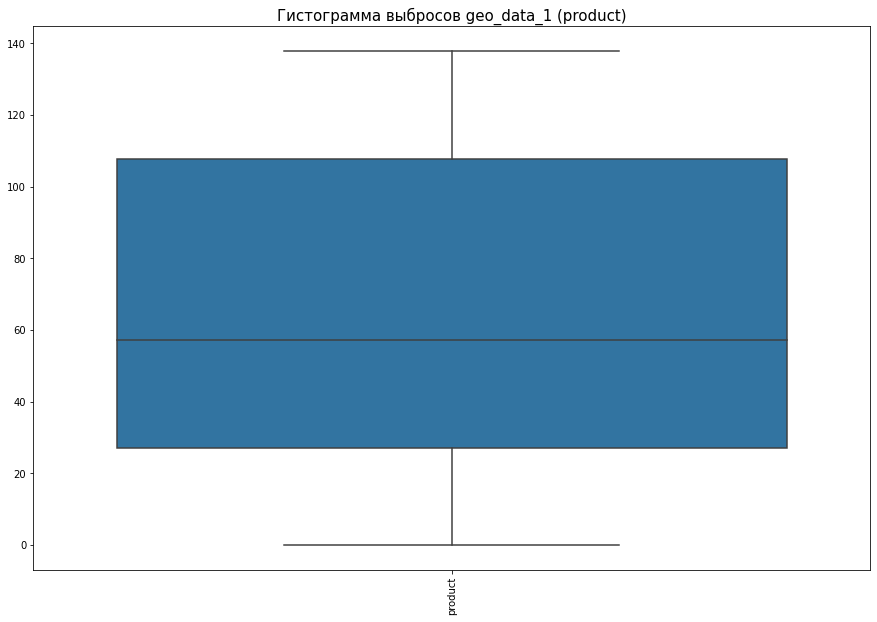

In [13]:
ax = sns.boxplot(data=geo_data_1.iloc[:,1:4])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Гистограмма выбросов geo_data_1 (f0, f1, f2)', size=15)
plt.show()
ax = sns.boxplot(data=geo_data_1.iloc[:,4:])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Гистограмма выбросов geo_data_1 (product)', size=15)
plt.show()

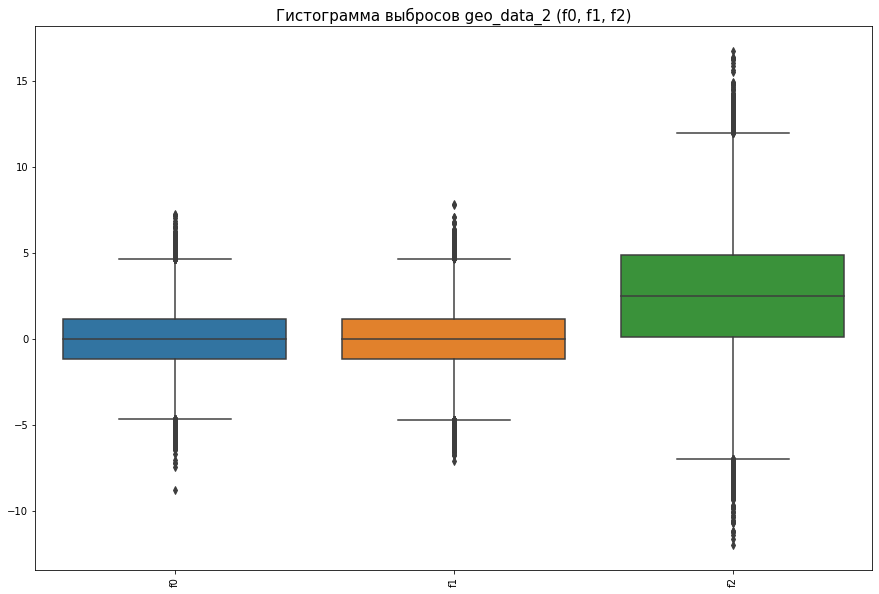

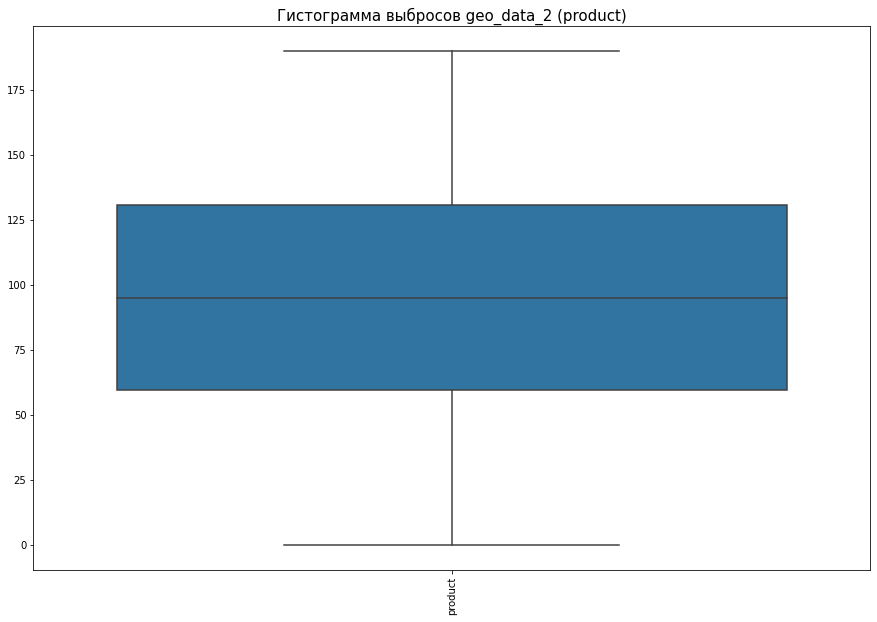

In [14]:
ax = sns.boxplot(data=geo_data_2.iloc[:,1:4])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Гистограмма выбросов geo_data_2 (f0, f1, f2)', size=15)
plt.show()
ax = sns.boxplot(data=geo_data_2.iloc[:,4:])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Гистограмма выбросов geo_data_2 (product)', size=15)
plt.show()

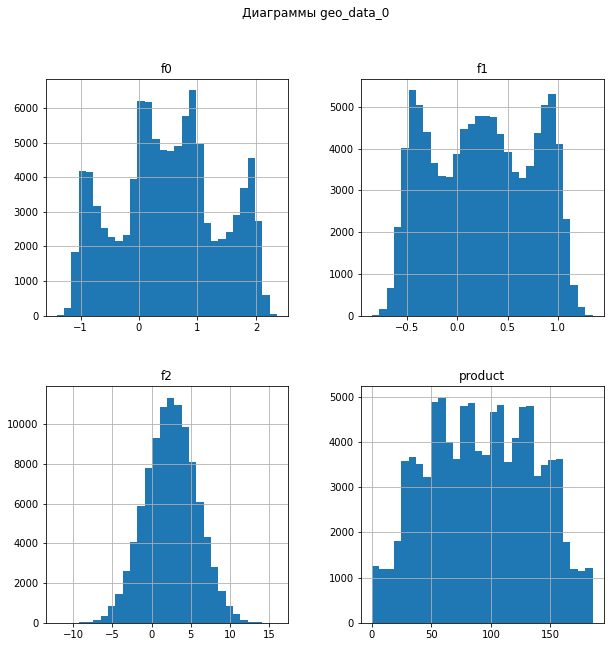

In [15]:
geo_data_0.iloc[:,1:].hist(figsize=(10, 10), bins=30)
plt.suptitle("Диаграммы geo_data_0");

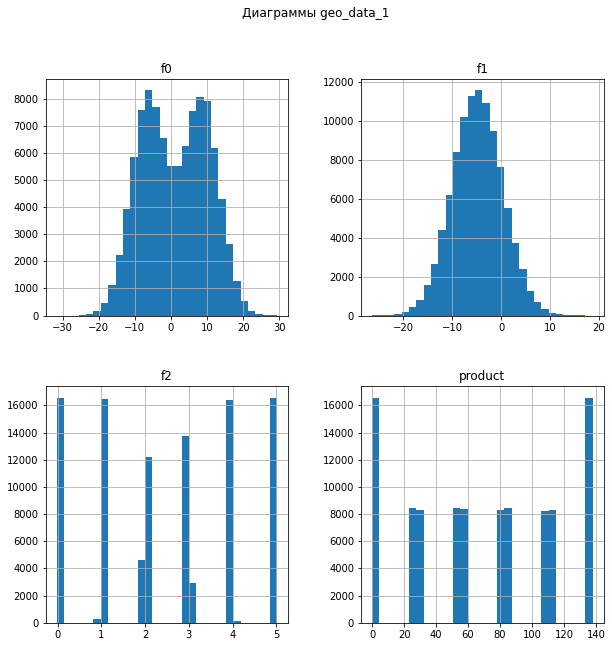

In [16]:
geo_data_1.iloc[:,1:].hist(figsize=(10, 10), bins=30)
plt.suptitle("Диаграммы geo_data_1");

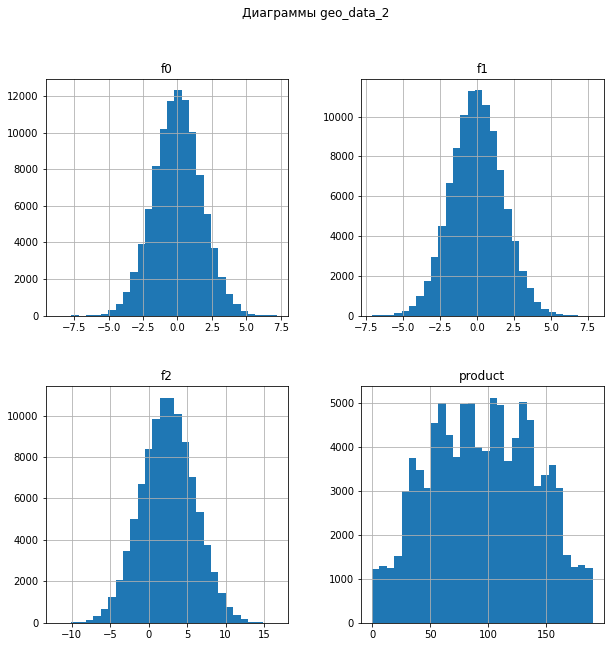

In [17]:
geo_data_2.iloc[:,1:].hist(figsize=(10, 10), bins=30)
plt.suptitle("Диаграммы geo_data_2");

In [18]:
geo_data_0.corr()

,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000


In [19]:
geo_data_1.corr()

,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000


In [20]:
geo_data_2.corr()

,f0,f1,f2,product
f0,1.000000,0.000528,-0.000448,-0.001987
f1,0.000528,1.000000,0.000779,-0.001012
f2,-0.000448,0.000779,1.000000,0.445871
product,-0.001987,-0.001012,0.445871,1.000000


<div class="alert alert-success">
<h2> Комментарий ревьюера ✔️ <a class="tocSkip"> </h2>

Очень правильное решение посмотреть корреляции. Хотя я бы еще построил диаграммы рассеивания. По ним можно обнаружить нелинейные зависимости, которые мы коэффициентами корреляции Пирсона не выявим

* Типы данных и наименования, во всех датафреймах, указаны верно;
* Пропусков, дубликатов не обнаружено;
* В geo_data_1 в продуктах более 12% значений ровны 0;
* Сильная корелляция у продукта с f2, особенно в geo_data_1;
* Выбросы. В geo_data_0 присутствуют значения, выше средних в колонке f2. В geo_data_1 присутствуют значения, выше средних в колонке f1. В geo_data_2 присутствуют значения, выше средних в колонках f1, f2, f3. Product во всех трёх датасетах в пределах нормы.

## Обучение и проверка модели

2. Обучите и проверьте модель для каждого региона:

    2.1. Разбейте данные на обучающую и валидационную выборки в соотношении 75:25.

    2.2. Обучите модель и сделайте предсказания на валидационной выборке.

    2.3. Сохраните предсказания и правильные ответы на валидационной выборке.

    2.4. Напечатайте на экране средний запас предсказанного сырья и RMSE модели.

    2.5. Проанализируйте результаты.

In [21]:
RANDOM_STATE = 42

Функция для разбития на тренировочную и валидационную выборки

In [22]:
def split_data(data):
    future = data.drop(['id', 'product'], axis=1)
    target = data['product']
    
    future_train, future_valid, target_train, target_valid = train_test_split(future, target, test_size=0.25, random_state=RANDOM_STATE, shuffle = True)
    return future_train, future_valid, target_train, target_valid

Разбиваем датасеты на тренировочную и валидационную выборки

In [23]:
future_train_0, future_valid_0, target_train_0, target_valid_0 = split_data(geo_data_0)
future_train_1, future_valid_1, target_train_1, target_valid_1 = split_data(geo_data_1)
future_train_2, future_valid_2, target_train_2, target_valid_2 = split_data(geo_data_2)

Обучим модель линейной регрессии

In [24]:
lr = LinearRegression()

In [25]:
def model_lr(future_train, future_valid, target_train, target_valid):
    lr.fit(future_train, target_train)
    predicted_valid = lr.predict(future_valid)
    
    mse = mean_squared_error(target_valid, predicted_valid)
    rmse = mean_squared_error(target_valid, predicted_valid)**0.5
    mean_sum = predicted_valid.sum()/len(predicted_valid)
    return mse, rmse, mean_sum, predicted_valid

In [26]:
mse_0, rmse_0, mean_sum_0, predicted_valid_0 = model_lr(future_train_0, future_valid_0, target_train_0, target_valid_0)
mse_1, rmse_1, mean_sum_1, predicted_valid_1 = model_lr(future_train_1, future_valid_1, target_train_1, target_valid_1)
mse_2, rmse_2, mean_sum_2, predicted_valid_2 = model_lr(future_train_2, future_valid_2, target_train_2, target_valid_2)

In [27]:
print(f'Регион geo_data_0: метрика MSE составляет {mse_0:.2f}, метрика RMSE составляет {rmse_0:.2f}, Средний запас сырья {mean_sum_0:.2f}')
print(f'Регион geo_data_1: метрика MSE составляет {mse_1:.2f}, метрика RMSE составляет {rmse_1:.2f}, Средний запас сырья {mean_sum_1:.2f}')
print(f'Регион geo_data_2: метрика MSE составляет {mse_2:.2f}, метрика RMSE составляет {rmse_2:.2f}, Средний запас сырья {mean_sum_2:.2f}')

Регион geo_data_0: метрика MSE составляет 1425.56, метрика RMSE составляет 37.76, Средний запас сырья 92.40
Регион geo_data_1: метрика MSE составляет 0.79, метрика RMSE составляет 0.89, Средний запас сырья 68.71
Регион geo_data_2: метрика MSE составляет 1611.69, метрика RMSE составляет 40.15, Средний запас сырья 94.77


In [28]:
print(f'Регион geo_data_0: метрика MSE составляет {mse_0:.2f}, метрика RMSE составляет {math.sqrt(mse_0):.2f}, Средний запас сырья {mean_sum_0:.2f}')
print(f'Регион geo_data_1: метрика MSE составляет {mse_1:.2f}, метрика RMSE составляет {math.sqrt(mse_1):.2f}, Средний запас сырья {mean_sum_1:.2f}')
print(f'Регион geo_data_2: метрика MSE составляет {mse_2:.2f}, метрика RMSE составляет {math.sqrt(mse_2):.2f}, Средний запас сырья {mean_sum_2:.2f}')

Регион geo_data_0: метрика MSE составляет 1425.56, метрика RMSE составляет 37.76, Средний запас сырья 92.40
Регион geo_data_1: метрика MSE составляет 0.79, метрика RMSE составляет 0.89, Средний запас сырья 68.71
Регион geo_data_2: метрика MSE составляет 1611.69, метрика RMSE составляет 40.15, Средний запас сырья 94.77


Лучше всего данные по geo_data_1, скорей всего из-за высокой корелляции между f2 и product

## Подготовка к расчёту прибыли

3. Подготовьтесь к расчёту прибыли:

    3.1. Все ключевые значения для расчётов сохраните в отдельных переменных.

    3.2. Рассчитайте достаточный объём сырья для безубыточной разработки новой скважины. Сравните полученный объём сырья со средним запасом в каждом регионе. 

    3.3. Напишите выводы по этапу подготовки расчёта прибыли.

In [29]:
MONEY = 10000000000
MONEY_BARREL = 450000
WELL = 200
WELL_MAX = 500
PRODUCT_UNITS_INCOME_RUB = 450 * 10**3 

In [30]:
raw_materials = MONEY/MONEY_BARREL/WELL 
print(f'Объём сырья для безубыточной разработки новой скважины: {raw_materials:.2f} баррель')

Объём сырья для безубыточной разработки новой скважины: 111.11 баррель


In [31]:
print(f'Объём сырья для безубыточной разработки новой скважины в geo_data_0: {mean_sum_0 - raw_materials:.2f} баррель')
print(f'Объём сырья для безубыточной разработки новой скважины в geo_data_1: {mean_sum_1 - raw_materials:.2f} баррель')
print(f'Объём сырья для безубыточной разработки новой скважины в geo_data_2: {mean_sum_2 - raw_materials:.2f} баррель')

Объём сырья для безубыточной разработки новой скважины в geo_data_0: -18.71 баррель
Объём сырья для безубыточной разработки новой скважины в geo_data_1: -42.40 баррель
Объём сырья для безубыточной разработки новой скважины в geo_data_2: -16.34 баррель


In [32]:
geo_data_0_good_product = ((geo_data_0.iloc[:,4:].query('product > 112').count())/len(geo_data_0)).to_list()
geo_data_1_good_product = ((geo_data_1.iloc[:,4:].query('product > 112').count())/len(geo_data_1)).to_list()
geo_data_2_good_product = ((geo_data_2.iloc[:,4:].query('product > 112').count())/len(geo_data_2)).to_list()

display(geo_data_0_good_product)
display(geo_data_1_good_product)
display(geo_data_2_good_product)

[0.35901]

[0.16537]

[0.37491]

Объём сырья для безубыточной разработки новой скважины равен чуть больше 111 баррелей, все локации не дотягивают до необходимых значений, больше всех в geo_data_1 \
geo_data_0 содержит 35.9% скважин с запасами нефти более 111 тысяч баррель. \
geo_data_1 содержит 16.5% скважин с запасами нефти более 111 тысяч баррель. \
geo_data_2 содержит 37.4% скважин с запасами нефти более 111 тысяч баррель.

## Расчёт прибыли и рисков 

4. Напишите функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели:

    4.1. Выберите скважины с максимальными значениями предсказаний. 
    
    4.2. Просуммируйте целевое значение объёма сырья, соответствующее этим предсказаниям.
    
    4.3. Рассчитайте прибыль для полученного объёма сырья.
    
    
5. Посчитайте риски и прибыль для каждого региона:

    5.1. Примените технику Bootstrap с 1000 выборок, чтобы найти распределение прибыли.
    
    5.2. Найдите среднюю прибыль, 95%-й доверительный интервал и риск убытков. Убыток — это отрицательная прибыль.
    
    5.3. Напишите выводы: предложите регион для разработки скважин и обоснуйте выбор.

In [33]:
def series_type(target, predicted):
    target = target.reset_index(drop=True)
    predicted = pd.Series(predicted)
    return target, predicted

In [34]:
target_valid_0, predicted_valid_0 = series_type(target_valid_0, predicted_valid_0)
target_valid_1, predicted_valid_1 = series_type(target_valid_1, predicted_valid_1)
target_valid_2, predicted_valid_2 = series_type(target_valid_2, predicted_valid_2)

In [35]:
def revenue(target, predictions, cost, count):
    probs_sorted = predictions.sort_values(ascending=False)
    deposits = target[probs_sorted.index][:count]
    return cost * deposits.sum() - MONEY

In [36]:
def bootstrap(target, predictions):
    state = np.random.RandomState(12345)

    values = []
    for i in range(1000):
        some_target = target.sample(n=WELL_MAX, replace=True, random_state=state)
        some_predictions = predictions[some_target.index]

        values.append(revenue(some_target, some_predictions, MONEY_BARREL, WELL))

    values = pd.Series(values)
    values_mean = round(values.mean(), 2)  
    lower = values.quantile(q=0.025)
    upper = values.quantile(q=0.975)
    risk = percentileofscore(values, 0, kind='rank') / 100  
    return values_mean, lower, upper, risk

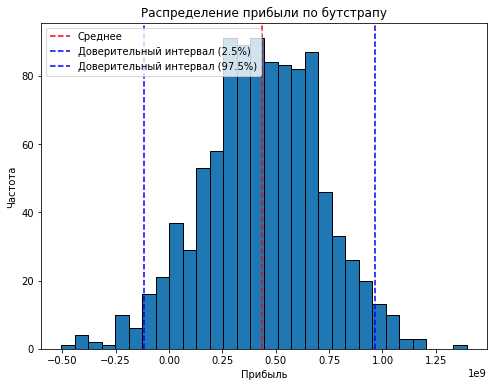

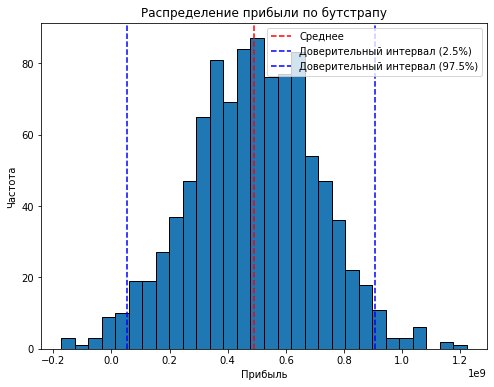

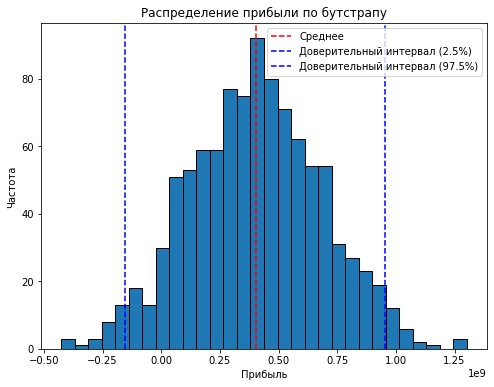

Регион geo_data_0: метрика MSE составляет 1425.56, метрика RMSE составляет 37.76, Средняя прибыль лучших месторождений 435933772.14, Средний запас сырья 92.40, Доверительный интервал: (-116231612.78, 966504180.71), Риск: 6.10%

Регион geo_data_1: метрика MSE составляет 0.79, метрика RMSE составляет 0.89, Средняя прибыль лучших месторождений 489661254.41, Средний запас сырья 68.71, Доверительный интервал: (55116177.27, 905762650.42), Риск: 1.10%

Регион geo_data_2: метрика MSE составляет 1611.69, метрика RMSE составляет 40.15, Средняя прибыль лучших месторождений 403687927.86, Средний запас сырья 94.77, Доверительный интервал: (-153116984.76, 952887416.71), Риск: 7.10%

Среднее значение по всем регионам: 443094318.14


In [37]:
def bootstrap(target, predictions):
    state = np.random.RandomState(12345)

    values = []
    for i in range(1000):
        some_target = target.sample(n=WELL_MAX, replace=True, random_state=state)
        some_predictions = predictions[some_target.index]

        values.append(revenue(some_target, some_predictions, MONEY_BARREL, WELL))

    values = pd.Series(values)
    values_mean = round(values.mean(), 2)
    lower = values.quantile(q=0.025)
    upper = values.quantile(q=0.975)
    risk = round((values < 0).mean() * 100, 2)

    plt.figure(figsize=(8, 6))
    plt.hist(values, bins=30, edgecolor='black')
    plt.title('Распределение прибыли по бутстрапу')
    plt.xlabel('Прибыль')
    plt.ylabel('Частота')

    plt.axvline(values_mean, color='red', linestyle='--', label='Среднее')
    plt.axvline(lower, color='blue', linestyle='--', label='Доверительный интервал (2.5%)')
    plt.axvline(upper, color='blue', linestyle='--', label='Доверительный интервал (97.5%)')

    plt.legend()
    plt.show()

    return values_mean, lower, upper, risk

values_mean_0, lower_0, upper_0, risk_0 = bootstrap(target_valid_0, predicted_valid_0)
values_mean_1, lower_1, upper_1, risk_1 = bootstrap(target_valid_1, predicted_valid_1)
values_mean_2, lower_2, upper_2, risk_2 = bootstrap(target_valid_2, predicted_valid_2)

print(f'Регион geo_data_0: метрика MSE составляет {mse_0:.2f}, метрика RMSE составляет {math.sqrt(mse_0):.2f}, Средняя прибыль лучших месторождений {values_mean_0:.2f}, Средний запас сырья {mean_sum_0:.2f}, Доверительный интервал: ({lower_0:.2f}, {upper_0:.2f}), Риск: {risk_0:.2f}%')
print()
print(f'Регион geo_data_1: метрика MSE составляет {mse_1:.2f}, метрика RMSE составляет {math.sqrt(mse_1):.2f}, Средняя прибыль лучших месторождений {values_mean_1:.2f}, Средний запас сырья {mean_sum_1:.2f}, Доверительный интервал: ({lower_1:.2f}, {upper_1:.2f}), Риск: {risk_1:.2f}%')
print()
print(f'Регион geo_data_2: метрика MSE составляет {mse_2:.2f}, метрика RMSE составляет {math.sqrt(mse_2):.2f}, Средняя прибыль лучших месторождений {values_mean_2:.2f}, Средний запас сырья {mean_sum_2:.2f}, Доверительный интервал: ({lower_2:.2f}, {upper_2:.2f}), Риск: {risk_2:.2f}%')

values_mean_all = (values_mean_0 + values_mean_1 + values_mean_2) / 3
print()
print(f'Среднее значение по всем регионам: {values_mean_all:.2f}')

## Общий вывод

В рамках исследований трёх месторождений для добычи полезных ископаемых была проведена работу по подготовке данных: \ 
проверены все входные данные и признаки, изучены пропуски, дубликаты и уникальные значения - особых проблем выявленно не было.
* Присутствуют небольшие выбросы в geo_data_0 (колонка f2), geo_data_1 (колонка f1), geo_data_2 (во всех колонках).
* Корелляция показала сильную зависимость в таблице geo_data_1 между product и f2

Построили модель линейной регрессии, целевым признаком выбрали Product. Метрики для анализа выбрали RMSE (среднеквадратическая ошибка) и MSE(среднеквадратическая ошибка), получились следующие данные:
* Регион geo_data_0: метрика MSE составляет 1425.56, метрика RMSE составляет 37.76, Средний запас сырья 92.40
* Регион geo_data_1: метрика MSE составляет 0.79, метрика RMSE составляет 0.89, Средний запас сырья 68.71
* Регион geo_data_2: метрика MSE составляет 1611.69, метрика RMSE составляет 40.15, Средний запас сырья 94.77 \
Лучше всего получились данные по geo_data_1

Расчитали объём сырья для безубыточной разработки новой скважины, он составил 111.11 тысяч баррель
* Объём сырья для безубыточной разработки новой скважины в geo_data_0: -18.71 баррель
* Объём сырья для безубыточной разработки новой скважины в geo_data_1: -42.40 баррель
* Объём сырья для безубыточной разработки новой скважины в geo_data_2: -16.34 баррель
* geo_data_0 содержит 35.9% скважин с запасами нефти более 111 тысяч баррель. 
* geo_data_1 содержит 16.5% скважин с запасами нефти более 111 тысяч баррель. 
* geo_data_2 содержит 37.4% скважин с запасами нефти более 111 тысяч баррель.

Написали функцию для подсчета прибыли для выбранных скважин(revenue). \

Посчитайли риски и прибыль для каждого региона
* Средняя прибыль лучших месторождений geo_data_0 равна: 435933772
* Средняя прибыль лучших месторождений geo_data_1 равна: 489661254
* Средняя прибыль лучших месторождений geo_data_2 равна: 403687927


* 95% доверительный интервал для средней прибыли 200 лучших месторождений geo_data_0: -116231612.78 - 966504180.71
* 95% доверительный интервал для средней прибыли 200 лучших месторождений geo_data_1: 55116177.27 - 905762650.42
* 95% доверительный интервал для средней прибыли 200 лучших месторождений geo_data_2: -153116984.76 - 952887416.71


* Риск убытков geo_data_0 равен: 6%
* Риск убытков geo_data_1 равен: 1%
* Риск убытков geo_data_2 равен: 7%


Делая общий вывод можно выделить регион geo_data_1, он имеет самую высокую средную прибыль (489661254), меньше всех риск убытков (1%), а так же самый низний разброс в доверительном интервале.